In [177]:
# loc - label based index
# iloc - value based index

Analyse the given dataset completely and perform the following questions.

1. Convert the text based categorical columns to numeric columns
2. Convert the Order Date column into Day, Month, Year and Time columns separately
3. Create a new column and store the Price data as rounded off in integer format
4. Create a new column and store the PIN Codes from the Address column
5. Create a new column named City and store the city names from the Address column
6. Group Product column into different categories such as Phones, Accessories, etc according to the data available.
7. Create 12 separate date ordered dataframes for every
8. What was the best month for sales? How much was earned that month? Explain via graph/chart
9. What city sold the most product?
10. What time should we display advertisements to maximize likelihood of customer’s buying product?
11. Which product was sold the least as per your categories and what might be the reason behind that. Explain your analysis.
12. Which product is most likely to be sold more during winter season, summer season and rainy season? Explain the possible reason behind the High-Volume Sale
13. Which phone is sold most during the month of March?
14. Which headphones are the most expensive?
15. Check if the price of any product is changing in different If yes, explain the possible reason behind the price change.
16. People prefer which product more in earphones, wired or wireless?
17. Which product in every category in more likely to be ordered in bulk?

















In [178]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [179]:
Sales_USA = pd.read_csv(filepath_or_buffer="C:/Users/dasgu/Project/Sales Dataset/SalesAnalysis.csv")

In [180]:
Sales_USA.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [181]:
Sales_USA.tail()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
186845,259353,AAA Batteries (4-pack),3,2.99,09/17/19 20:56,"840 Highland St, Los Angeles, CA 90001"
186846,259354,iPhone,1,700,09/01/19 16:00,"216 Dogwood St, San Francisco, CA 94016"
186847,259355,iPhone,1,700,09/23/19 07:39,"220 12th St, San Francisco, CA 94016"
186848,259356,34in Ultrawide Monitor,1,379.99,09/19/19 17:30,"511 Forest St, San Francisco, CA 94016"
186849,259357,USB-C Charging Cable,1,11.95,09/30/19 00:18,"250 Meadow St, San Francisco, CA 94016"


## Cleaning the Data

In [182]:
Sales_USA.dtypes

Order ID            object
Product             object
Quantity Ordered    object
Price Each          object
Order Date          object
Purchase Address    object
dtype: object

We see that all the data are in object format. We need to convert them into relevant data type

In [183]:
Sales_USA.Product.value_counts()

Product
USB-C Charging Cable          21903
Lightning Charging Cable      21658
AAA Batteries (4-pack)        20641
AA Batteries (4-pack)         20577
Wired Headphones              18882
Apple Airpods Headphones      15549
Bose SoundSport Headphones    13325
27in FHD Monitor               7507
iPhone                         6842
27in 4K Gaming Monitor         6230
34in Ultrawide Monitor         6181
Google Phone                   5525
Flatscreen TV                  4800
Macbook Pro Laptop             4724
ThinkPad Laptop                4128
20in Monitor                   4101
Vareebadd Phone                2065
LG Washing Machine              666
LG Dryer                        646
Product                         355
Name: count, dtype: int64

In [184]:
Sales_USA["Quantity Ordered"].value_counts()

Quantity Ordered
1                   168552
2                    13324
3                     2920
4                      806
Quantity Ordered       355
5                      236
6                       80
7                       24
8                        5
9                        3
Name: count, dtype: int64

In [185]:
Sales_USA["Product"].value_counts()

Product
USB-C Charging Cable          21903
Lightning Charging Cable      21658
AAA Batteries (4-pack)        20641
AA Batteries (4-pack)         20577
Wired Headphones              18882
Apple Airpods Headphones      15549
Bose SoundSport Headphones    13325
27in FHD Monitor               7507
iPhone                         6842
27in 4K Gaming Monitor         6230
34in Ultrawide Monitor         6181
Google Phone                   5525
Flatscreen TV                  4800
Macbook Pro Laptop             4724
ThinkPad Laptop                4128
20in Monitor                   4101
Vareebadd Phone                2065
LG Washing Machine              666
LG Dryer                        646
Product                         355
Name: count, dtype: int64

In [186]:
Sales_USA["Price Each"].value_counts()

Price Each
11.95         21903
14.95         21658
2.99          20641
3.84          20577
11.99         18882
150           15450
99.99         13325
149.99         7507
700            6804
389.99         6230
379.99         6181
600            5490
300            4780
1700           4702
999.99         4128
109.99         4101
400            2056
600.0          1347
Price Each      355
150.0            99
700.0            38
1700.0           22
300.0            20
400.0             9
Name: count, dtype: int64

Here we see that an item named "Product" is coming 355 times in the data. Similarly , here we see that "Quantity ordered" is occuring 355 in the data which can be a mistake so first we will observe and then remove those specific column with irrelevant data. Here we see "Price each" is also repeating 355 times .

### Removing irrelevant rows

In [187]:
index_removed= Sales_USA[Sales_USA["Quantity Ordered"] == "Quantity Ordered"]
index_removed.head(10)


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
519,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1149,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1155,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
2878,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
2893,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
3036,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
3209,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
3618,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
4138,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
4645,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address


In [188]:
index_removed


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
519,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1149,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1155,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
2878,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
2893,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
...,...,...,...,...,...,...
185164,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
185551,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
186563,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
186632,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address


In [189]:
Sales_USA = Sales_USA[Sales_USA["Quantity Ordered"] != "Quantity Ordered"]

In [190]:
Sales_USA

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.99,09/17/19 20:56,"840 Highland St, Los Angeles, CA 90001"
186846,259354,iPhone,1,700,09/01/19 16:00,"216 Dogwood St, San Francisco, CA 94016"
186847,259355,iPhone,1,700,09/23/19 07:39,"220 12th St, San Francisco, CA 94016"
186848,259356,34in Ultrawide Monitor,1,379.99,09/19/19 17:30,"511 Forest St, San Francisco, CA 94016"


In [191]:
Sales_USA["Quantity Ordered"].value_counts()

Quantity Ordered
1    168552
2     13324
3      2920
4       806
5       236
6        80
7        24
8         5
9         3
Name: count, dtype: int64

### clean and reset the index:

In [192]:
Sales_USA.reset_index(drop=True)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
...,...,...,...,...,...,...
186490,259353,AAA Batteries (4-pack),3,2.99,09/17/19 20:56,"840 Highland St, Los Angeles, CA 90001"
186491,259354,iPhone,1,700,09/01/19 16:00,"216 Dogwood St, San Francisco, CA 94016"
186492,259355,iPhone,1,700,09/23/19 07:39,"220 12th St, San Francisco, CA 94016"
186493,259356,34in Ultrawide Monitor,1,379.99,09/19/19 17:30,"511 Forest St, San Francisco, CA 94016"


### Handling missing Data

In [193]:
Sales_USA.isnull().sum()

Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          545
Purchase Address    545
dtype: int64

545 missing values in each column . We will remove them by using dropna

In [194]:
Sales_USA.dropna(inplace = True)
Sales_USA.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"


In [195]:
Sales_USA

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"
...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.99,09/17/19 20:56,"840 Highland St, Los Angeles, CA 90001"
186846,259354,iPhone,1,700,09/01/19 16:00,"216 Dogwood St, San Francisco, CA 94016"
186847,259355,iPhone,1,700,09/23/19 07:39,"220 12th St, San Francisco, CA 94016"
186848,259356,34in Ultrawide Monitor,1,379.99,09/19/19 17:30,"511 Forest St, San Francisco, CA 94016"


In [196]:
Sales_USA.isnull().sum()

Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
dtype: int64

In [197]:
Sales_USA.reset_index(drop=True)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
2,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
3,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"
...,...,...,...,...,...,...
185945,259353,AAA Batteries (4-pack),3,2.99,09/17/19 20:56,"840 Highland St, Los Angeles, CA 90001"
185946,259354,iPhone,1,700,09/01/19 16:00,"216 Dogwood St, San Francisco, CA 94016"
185947,259355,iPhone,1,700,09/23/19 07:39,"220 12th St, San Francisco, CA 94016"
185948,259356,34in Ultrawide Monitor,1,379.99,09/19/19 17:30,"511 Forest St, San Francisco, CA 94016"


In [198]:
Sales_USA

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"
...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.99,09/17/19 20:56,"840 Highland St, Los Angeles, CA 90001"
186846,259354,iPhone,1,700,09/01/19 16:00,"216 Dogwood St, San Francisco, CA 94016"
186847,259355,iPhone,1,700,09/23/19 07:39,"220 12th St, San Francisco, CA 94016"
186848,259356,34in Ultrawide Monitor,1,379.99,09/19/19 17:30,"511 Forest St, San Francisco, CA 94016"


### Finding and Dropping Duplicate Values



In [199]:
### https://medium.com/@heyamit10/understanding-pandas-duplicated-with-examples-9f96edc58010

In [200]:
Sales_USA.duplicated().sum()   # how many duplicate rows are there

264

In [201]:
Sales_USA.duplicated() # returns a panda series of boolean values

0         False
2         False
3         False
4         False
5         False
          ...  
186845    False
186846    False
186847    False
186848    False
186849    False
Length: 185950, dtype: bool

In [202]:
duplicate_list = Sales_USA[Sales_USA.duplicated()]
duplicate_list                                          # returns a dataframe containing where the condition is true

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
31,176585,Bose SoundSport Headphones,1,99.99,04/07/19 11:31,"823 Highland St, Boston, MA 02215"
1302,177795,Apple Airpods Headphones,1,150,04/27/19 19:45,"740 14th St, Seattle, WA 98101"
1684,178158,USB-C Charging Cable,1,11.95,04/28/19 21:13,"197 Center St, San Francisco, CA 94016"
3805,180207,Apple Airpods Headphones,1,150,04/13/19 01:46,"196 7th St, Los Angeles, CA 90001"
4196,180576,Lightning Charging Cable,1,14.95,04/18/19 17:23,"431 Park St, Dallas, TX 75001"
...,...,...,...,...,...,...
184940,257530,USB-C Charging Cable,1,11.95,09/03/19 11:13,"192 Johnson St, San Francisco, CA 94016"
186173,258715,Lightning Charging Cable,1,14.95,09/15/19 16:50,"550 10th St, Portland, OR 97035"
186508,259035,27in FHD Monitor,1,149.99,09/29/19 13:52,"327 Lake St, San Francisco, CA 94016"
186782,259296,Apple Airpods Headphones,1,150,09/28/19 16:48,"894 6th St, Dallas, TX 75001"


#### Finding duplicates on the basis of columns

In [203]:
multi_col_duplicates = Sales_USA.duplicated(subset=['Order ID'])    # multicolumn duplicates
multi_col_duplicates.sum()  # Counting the numbe rof duplicates


7513

In [204]:
multi_col_duplicates =  Sales_USA[Sales_USA.duplicated(subset=['Order ID'])] 
multi_col_duplicates                                                           # returns a dataframe containing where the condition is true

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
19,176574,USB-C Charging Cable,1,11.95,04/03/19 19:42,"20 Hill St, Los Angeles, CA 90001"
31,176585,Bose SoundSport Headphones,1,99.99,04/07/19 11:31,"823 Highland St, Boston, MA 02215"
33,176586,Google Phone,1,600,04/10/19 17:00,"365 Center St, San Francisco, CA 94016"
120,176672,USB-C Charging Cable,1,11.95,04/12/19 11:07,"778 Maple St, New York City, NY 10001"
...,...,...,...,...,...,...
186784,259297,Lightning Charging Cable,1,14.95,09/15/19 18:54,"138 Main St, Boston, MA 02215"
186785,259297,Lightning Charging Cable,1,14.95,09/15/19 18:54,"138 Main St, Boston, MA 02215"
186792,259303,AA Batteries (4-pack),1,3.84,09/20/19 20:18,"106 7th St, Atlanta, GA 30301"
186804,259314,AAA Batteries (4-pack),2,2.99,09/16/19 00:25,"241 Highland St, Atlanta, GA 30301"


### Removing Duplicate Rows

In [205]:
Sales_USA = Sales_USA.drop_duplicates()
Sales_USA

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"
...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.99,09/17/19 20:56,"840 Highland St, Los Angeles, CA 90001"
186846,259354,iPhone,1,700,09/01/19 16:00,"216 Dogwood St, San Francisco, CA 94016"
186847,259355,iPhone,1,700,09/23/19 07:39,"220 12th St, San Francisco, CA 94016"
186848,259356,34in Ultrawide Monitor,1,379.99,09/19/19 17:30,"511 Forest St, San Francisco, CA 94016"


In [206]:
Sales_USA.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185686 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          185686 non-null  object
 1   Product           185686 non-null  object
 2   Quantity Ordered  185686 non-null  object
 3   Price Each        185686 non-null  object
 4   Order Date        185686 non-null  object
 5   Purchase Address  185686 non-null  object
dtypes: object(6)
memory usage: 9.9+ MB


We observe that all the columns are in object format. 

#### 1.Data Type Conversion

In [207]:
Sales_USA = Sales_USA.copy()

In [208]:
Sales_USA['Order ID'] = Sales_USA['Order ID'].astype('int64')
Sales_USA['Quantity Ordered'] = Sales_USA['Quantity Ordered'].astype('int64')
Sales_USA['Price Each'] = Sales_USA['Price Each'].astype('float64')
Sales_USA.dtypes


Order ID              int64
Product              object
Quantity Ordered      int64
Price Each          float64
Order Date           object
Purchase Address     object
dtype: object

#### Label Encoding of Product Column

The 'Product' column is label-encoded, converting each unique product name into a unique numeric identifier, stored in the new 'productnum' column. This transformation allows the categorical product data to be used in numerical analyses and machine learning models.

In [209]:
a= Sales_USA.Product.unique().tolist()
def productnum(product_name):
    global a
    return a.index(product_name)+1                              # find where this product exists in list a

Sales_USA['product_no'] = Sales_USA.Product.apply(productnum)
                                                               # create a new col named prduct_no and applies the function to each row of Product column
Sales_USA.head()                                                                # of the original data


# for reading variable global a not needed for modifying variable outside the function , global variable is needed.
    

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,product_no
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",1
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",2
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",3
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4


Task 2. Convert the Order Date column into Day, Month, Year and Time columns separately .

#### Converting Order Date to DateTime Format

In [210]:
Sales_USA["Order Date"] = pd.to_datetime(Sales_USA["Order Date"])      # format='%Y-%m-%d %H:%M:%S')
Sales_USA.head()

C:\Users\dasgu\AppData\Local\Temp\ipykernel_22048\3576719811.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Sales_USA["Order Date"] = pd.to_datetime(Sales_USA["Order Date"])      # format='%Y-%m-%d %H:%M:%S')


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,product_no
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",1
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",2
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",3
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4


In [211]:
Sales_USA.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185686 entries, 0 to 186849
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          185686 non-null  int64         
 1   Product           185686 non-null  object        
 2   Quantity Ordered  185686 non-null  int64         
 3   Price Each        185686 non-null  float64       
 4   Order Date        185686 non-null  datetime64[ns]
 5   Purchase Address  185686 non-null  object        
 6   product_no        185686 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 11.3+ MB


#### Extracting Day, Month, Year, and Time Components

In [212]:
Sales_USA["Day"] = Sales_USA["Order Date"].dt.day
Sales_USA["Month"] = Sales_USA["Order Date"].dt.month
Sales_USA["Year"] = Sales_USA["Order Date"].dt.year
Sales_USA["Time"] = Sales_USA["Order Date"].dt.time
Sales_USA.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,product_no,Day,Month,Year,Time
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",1,19,4,2019,08:46:00
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",2,7,4,2019,22:30:00
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",3,12,4,2019,14:38:00
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,12,4,2019,14:38:00
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,30,4,2019,09:27:00


##### Task 3. Create a new column and store the Price data as rounded off in integer format

In [213]:
Sales_USA["Price Rounded"] = Sales_USA["Price Each"].round().astype(int)

In [214]:
Sales_USA.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,product_no,Day,Month,Year,Time,Price Rounded
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",1,19,4,2019,08:46:00,12
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",2,7,4,2019,22:30:00,100
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",3,12,4,2019,14:38:00,600
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,12,4,2019,14:38:00,12
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,30,4,2019,09:27:00,12


##### Task 4. Create a new column and store the PIN Codes from the Address column

In [215]:
# expand : If set to True , it returns the split parts as separate columns in a DataFrame. If False , you get a list within the same column.

In [216]:
address = Sales_USA["Purchase Address"].str.split(",", expand = True)
address


,0,1,2
0,917 1st St,Dallas,TX 75001
2,682 Chestnut St,Boston,MA 02215
3,669 Spruce St,Los Angeles,CA 90001
4,669 Spruce St,Los Angeles,CA 90001
5,333 8th St,Los Angeles,CA 90001
...,...,...,...
186845,840 Highland St,Los Angeles,CA 90001
186846,216 Dogwood St,San Francisco,CA 94016
186847,220 12th St,San Francisco,CA 94016
186848,511 Forest St,San Francisco,CA 94016


In [217]:
pin = address[2].str.split(" ",expand = True)
pin.head()

,0,1,2
0,,TX,75001
2,,MA,02215
3,,CA,90001
4,,CA,90001
5,,CA,90001


In [218]:
Sales_USA["Pin"] = pin[2]
Sales_USA.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,product_no,Day,Month,Year,Time,Price Rounded,Pin
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",1,19,4,2019,08:46:00,12,75001
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",2,7,4,2019,22:30:00,100,02215
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",3,12,4,2019,14:38:00,600,90001
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,12,4,2019,14:38:00,12,90001
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,30,4,2019,09:27:00,12,90001


##### Task 5. Create a new column named City and store the city names from the Address column

In [219]:
Sales_USA["City"] = address[1]
Sales_USA.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,product_no,Day,Month,Year,Time,Price Rounded,Pin,City
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",1,19,4,2019,08:46:00,12,75001,Dallas
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",2,7,4,2019,22:30:00,100,02215,Boston
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",3,12,4,2019,14:38:00,600,90001,Los Angeles
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,12,4,2019,14:38:00,12,90001,Los Angeles
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,30,4,2019,09:27:00,12,90001,Los Angeles


##### Task 6. Group Product column into different categories such as Phones, Accessories, etc according to the data available.

1st we will identify the unique list of products

In [220]:
Sales_USA.Product.unique().tolist()

['USB-C Charging Cable',
 'Bose SoundSport Headphones',
 'Google Phone',
 'Wired Headphones',
 'Macbook Pro Laptop',
 'Lightning Charging Cable',
 '27in 4K Gaming Monitor',
 'AA Batteries (4-pack)',
 'Apple Airpods Headphones',
 'AAA Batteries (4-pack)',
 'iPhone',
 'Flatscreen TV',
 '27in FHD Monitor',
 '20in Monitor',
 'LG Dryer',
 'ThinkPad Laptop',
 'Vareebadd Phone',
 'LG Washing Machine',
 '34in Ultrawide Monitor']

Defining the Product Grouping Function

In [221]:
def grpproduct(product):
    if product in ['USB-C Charging Cable','Lightning Charging Cable']:
        return "Charging Cable"
    elif product in ['Bose SoundSport Headphones','Wired Headphones','Apple Airpods Headphones']:
        return "Headphone"
    elif product in ['Google Phone','iPhone','Vareebadd Phone']:
        return "Phone"
    elif product in ['Macbook Pro Laptop','ThinkPad Laptop']:
        return "Laptop"
    elif product in ['27in 4K Gaming Monitor','27in FHD Monitor','20in Monitor','34in Ultrawide Monitor']:
        return "Monitor"
    elif product in ['AA Batteries (4-pack)','AAA Batteries (4-pack)']:
        return "Batteries"
    elif product in ['Flatscreen TV']:
        return "TV"
    elif product in ['LG Dryer','LG Washing Machine']:
        return "Home Appliances"
    else:
        return np.nan
    
    

In [222]:
Sales_USA['Product Category'] = Sales_USA.Product.apply(grpproduct)
Sales_USA

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,product_no,Day,Month,Year,Time,Price Rounded,Pin,City,Product Category
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",1,19,4,2019,08:46:00,12,75001,Dallas,Charging Cable
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",2,7,4,2019,22:30:00,100,02215,Boston,Headphone
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",3,12,4,2019,14:38:00,600,90001,Los Angeles,Phone
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,12,4,2019,14:38:00,12,90001,Los Angeles,Headphone
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,30,4,2019,09:27:00,12,90001,Los Angeles,Headphone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.99,2019-09-17 20:56:00,"840 Highland St, Los Angeles, CA 90001",10,17,9,2019,20:56:00,3,90001,Los Angeles,Batteries
186846,259354,iPhone,1,700.00,2019-09-01 16:00:00,"216 Dogwood St, San Francisco, CA 94016",11,1,9,2019,16:00:00,700,94016,San Francisco,Phone
186847,259355,iPhone,1,700.00,2019-09-23 07:39:00,"220 12th St, San Francisco, CA 94016",11,23,9,2019,07:39:00,700,94016,San Francisco,Phone
186848,259356,34in Ultrawide Monitor,1,379.99,2019-09-19 17:30:00,"511 Forest St, San Francisco, CA 94016",19,19,9,2019,17:30:00,380,94016,San Francisco,Monitor


#### Task 7. Create 12 separate date ordered dataframes for every month.

In [223]:
Sales_USA.Year.unique().tolist()

[2019, 2020]

In [224]:
Sales_USA19 = Sales_USA[Sales_USA.Year==2019]
Sales_USA20 = Sales_USA[Sales_USA.Year==2020]       # Filtering data by Year

In [225]:
ds_list={}
monthnum=[1,2,3,4,5,6,7,8,9,10,11,12]
monthlist=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]


In [226]:
for i in monthnum:
    ds_list[monthlist[i-1]]= Sales_USA[Sales_USA["Month"] == i]         # when Month = 1 get monthlist index of 0 and so on

In [227]:
ds_list["Jan"].head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,product_no,Day,Month,Year,Time,Price Rounded,Pin,City,Product Category
31957,297150,Lightning Charging Cable,1,14.95,2020-01-01 00:38:00,"427 Wilson St, Dallas, TX 75001",6,1,1,2020,00:38:00,15,75001,Dallas,Charging Cable
32659,297817,iPhone,1,700.00,2020-01-01 00:22:00,"519 13th St, New York City, NY 10001",11,1,1,2020,00:22:00,700,10001,New York City,Phone
32660,297817,Lightning Charging Cable,2,14.95,2020-01-01 00:22:00,"519 13th St, New York City, NY 10001",6,1,1,2020,00:22:00,15,10001,New York City,Charging Cable
32819,297969,Google Phone,1,600.00,2020-01-01 00:54:00,"542 2nd St, San Francisco, CA 94016",3,1,1,2020,00:54:00,600,94016,San Francisco,Phone
33200,298344,Wired Headphones,4,11.99,2020-01-01 03:34:00,"731 7th St, New York City, NY 10001",4,1,1,2020,03:34:00,12,10001,New York City,Headphone


Displaying Januray Dataframe

#### Task 8. What was the best month for sales? How much was earned that month? Explain via graph/chart

In [228]:
Sales_USA["Total Sales"] = Sales_USA["Quantity Ordered"] * Sales_USA["Price Rounded"]
Sales_USA

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,product_no,Day,Month,Year,Time,Price Rounded,Pin,City,Product Category,Total Sales
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",1,19,4,2019,08:46:00,12,75001,Dallas,Charging Cable,24
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",2,7,4,2019,22:30:00,100,02215,Boston,Headphone,100
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",3,12,4,2019,14:38:00,600,90001,Los Angeles,Phone,600
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,12,4,2019,14:38:00,12,90001,Los Angeles,Headphone,12
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,30,4,2019,09:27:00,12,90001,Los Angeles,Headphone,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.99,2019-09-17 20:56:00,"840 Highland St, Los Angeles, CA 90001",10,17,9,2019,20:56:00,3,90001,Los Angeles,Batteries,9
186846,259354,iPhone,1,700.00,2019-09-01 16:00:00,"216 Dogwood St, San Francisco, CA 94016",11,1,9,2019,16:00:00,700,94016,San Francisco,Phone,700
186847,259355,iPhone,1,700.00,2019-09-23 07:39:00,"220 12th St, San Francisco, CA 94016",11,23,9,2019,07:39:00,700,94016,San Francisco,Phone,700
186848,259356,34in Ultrawide Monitor,1,379.99,2019-09-19 17:30:00,"511 Forest St, San Francisco, CA 94016",19,19,9,2019,17:30:00,380,94016,San Francisco,Monitor,380


In [229]:
sale = Sales_USA.groupby("Month")["Total Sales"].sum()
sale

Month
1     1821811
2     2200572
3     2805594
4     3389991
5     3151289
6     2576850
7     2647047
8     2241581
9     2094958
10    3735611
11    3198606
12    4609333
Name: Total Sales, dtype: int64

In [230]:
sale.max()

4609333

In [231]:
sale.idxmax()    # Give me the INDEX/LABEL where the maximum value exists.

12

In [232]:
sale.idxmin()  

1

December month has the highest number of sales of 4609333.

In [233]:
Sorted_df = Sales_USA.sort_values(by = "Total Sales", ascending = False) # if you want to sort by any column
Sorted_df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,product_no,Day,Month,Year,Time,Price Rounded,Pin,City,Product Category,Total Sales
92026,210292,Macbook Pro Laptop,2,1700.00,2019-06-08 09:00:00,"953 Ridge St, San Francisco, CA 94016",5,8,6,2019,09:00:00,1700,94016,San Francisco,Laptop,3400
4717,181069,Macbook Pro Laptop,2,1700.00,2019-04-27 21:01:00,"668 Park St, San Francisco, CA 94016",5,27,4,2019,21:01:00,1700,94016,San Francisco,Laptop,3400
127265,200528,Macbook Pro Laptop,2,1700.00,2019-05-13 13:40:00,"643 4th St, Boston, MA 02215",5,13,5,2019,13:40:00,1700,02215,Boston,Laptop,3400
5219,181544,Macbook Pro Laptop,2,1700.00,2019-04-22 12:48:00,"731 11th St, New York City, NY 10001",5,22,4,2019,12:48:00,1700,10001,New York City,Laptop,3400
76338,149611,ThinkPad Laptop,2,999.99,2019-01-31 17:47:00,"850 6th St, New York City, NY 10001",16,31,1,2019,17:47:00,1000,10001,New York City,Laptop,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173556,277259,AAA Batteries (4-pack),1,2.99,2019-10-11 06:02:00,"557 Wilson St, New York City, NY 10001",10,11,10,2019,06:02:00,3,10001,New York City,Batteries,3
77044,150284,AAA Batteries (4-pack),1,2.99,2019-01-03 08:21:00,"462 Highland St, San Francisco, CA 94016",10,3,1,2019,08:21:00,3,94016,San Francisco,Batteries,3
11264,187314,AAA Batteries (4-pack),1,2.99,2019-04-06 09:15:00,"522 Madison St, New York City, NY 10001",10,6,4,2019,09:15:00,3,10001,New York City,Batteries,3
96698,214716,AAA Batteries (4-pack),1,2.99,2019-06-14 12:42:00,"73 Jefferson St, Los Angeles, CA 90001",10,14,6,2019,12:42:00,3,90001,Los Angeles,Batteries,3


#### Bar Chart of Sales By Month

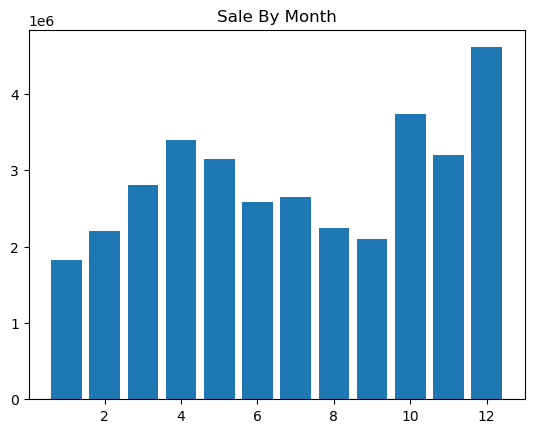

In [234]:
x = sale.index
y = sale.values
plt.bar(x,y)
plt.title('Sale By Month')
plt.show()

Using Seaborn

<Axes: xlabel='Month'>

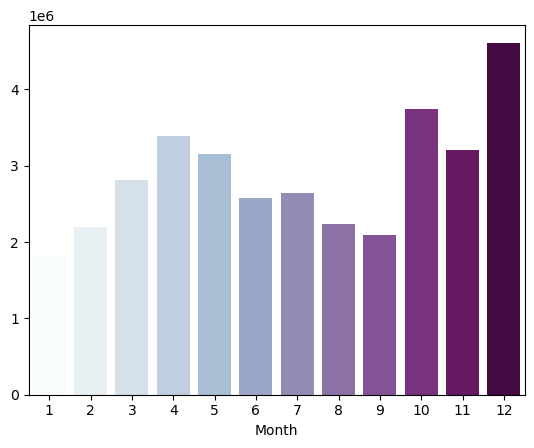

In [235]:
sns.barplot(x = sale.index , y = sale.values , hue = sale.index, palette ='BuPu', legend = False)   # hue means Color bars based on x values.

Conclusion :
Based on the calculated total sales for each month, the results indicate the following:

The month with the highest sales is December, with total earnings of 4,608,295.70.
The month with the second highest sales is October, with total earnings of 3,734,777.86.
The month with the lowest sales is January, with total earnings of 1,821,413.16.

##### Task 9. What city sold the most product?

The task is to identify the city with the highest product sales and visualize the distribution of sales across different cities.

In [236]:
Sales_USA

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,product_no,Day,Month,Year,Time,Price Rounded,Pin,City,Product Category,Total Sales
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",1,19,4,2019,08:46:00,12,75001,Dallas,Charging Cable,24
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",2,7,4,2019,22:30:00,100,02215,Boston,Headphone,100
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",3,12,4,2019,14:38:00,600,90001,Los Angeles,Phone,600
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,12,4,2019,14:38:00,12,90001,Los Angeles,Headphone,12
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,30,4,2019,09:27:00,12,90001,Los Angeles,Headphone,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.99,2019-09-17 20:56:00,"840 Highland St, Los Angeles, CA 90001",10,17,9,2019,20:56:00,3,90001,Los Angeles,Batteries,9
186846,259354,iPhone,1,700.00,2019-09-01 16:00:00,"216 Dogwood St, San Francisco, CA 94016",11,1,9,2019,16:00:00,700,94016,San Francisco,Phone,700
186847,259355,iPhone,1,700.00,2019-09-23 07:39:00,"220 12th St, San Francisco, CA 94016",11,23,9,2019,07:39:00,700,94016,San Francisco,Phone,700
186848,259356,34in Ultrawide Monitor,1,379.99,2019-09-19 17:30:00,"511 Forest St, San Francisco, CA 94016",19,19,9,2019,17:30:00,380,94016,San Francisco,Monitor,380


In [237]:

sale_by_city = Sales_USA.City.value_counts()
sale_by_city




City
San Francisco    44662
Los Angeles      29564
New York City    24847
Boston           19901
Atlanta          14863
Dallas           14797
Seattle          14713
Portland         12449
Austin            9890
Name: count, dtype: int64

The output indicates that San Francisco has the highest number of sales transactions (44,662), followed by Los Angeles (29,564) and New York City (24,847). This step helps identify the city with the most sales activity.

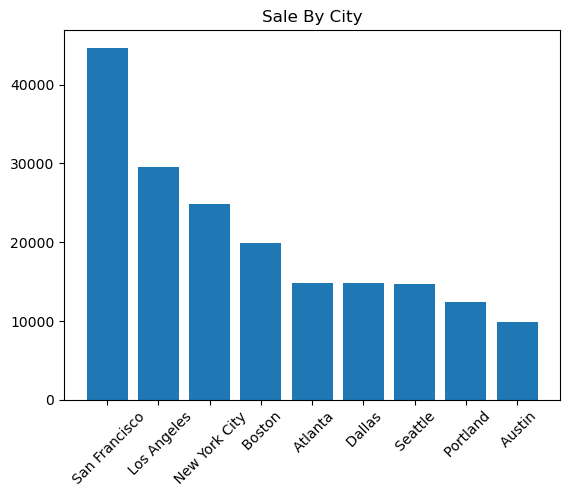

<Figure size 640x480 with 0 Axes>

In [238]:
x = sale_by_city.index
y = sale_by_city.values
# plt.figure(figsize=(10,5)) --- to increase figure size
plt.xticks(rotation=45)  # rotates city names by 45 degrees. 90 degree - vertical 0 - normal 
plt.bar(x,y)
plt.title("Sale By City")
plt.show()
plt.savefig("Sales_By_City.png")

San Francisco is clearly the city with the highest sales volume, as reflected by the tallest bar in the plot. This visualization provides a clear comparison of sales performance by city, highlighting San Francisco as the leading city in terms of product sales.

Conclusion :
The analysis reveals that San Francisco leads in sales transactions compared to other cities. The visual representation confirms this by showing San Francisco's prominent position in the sales distribution, making it evident which city contributes the most to the overall sales figures.

#### Task 10. What time should we display advertisements to maximize likelihood of customer's buying product?

The task aims to determine the optimal time to display advertisements by analyzing the hourly distribution of purchases to maximize the likelihood of customers buying products.

In [239]:
Sales_USA["Hour"]= Sales_USA["Order Date"].dt.hour
Sales_USA.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,product_no,Day,Month,Year,Time,Price Rounded,Pin,City,Product Category,Total Sales,Hour
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",1,19,4,2019,08:46:00,12,75001,Dallas,Charging Cable,24,8
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",2,7,4,2019,22:30:00,100,02215,Boston,Headphone,100,22
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",3,12,4,2019,14:38:00,600,90001,Los Angeles,Phone,600,14
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,12,4,2019,14:38:00,12,90001,Los Angeles,Headphone,12,14
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,30,4,2019,09:27:00,12,90001,Los Angeles,Headphone,12,9


In [240]:
Hourly_Purchase = Sales_USA.Hour.value_counts()
Hourly_Purchase

Hour
19    12886
12    12573
11    12392
18    12263
20    12218
13    12115
14    10965
10    10929
21    10905
17    10884
16    10359
15    10159
22     8808
9      8740
23     6262
8      6252
7      4002
0      3902
6      2481
1      2347
5      1320
2      1242
4       852
3       830
Name: count, dtype: int64

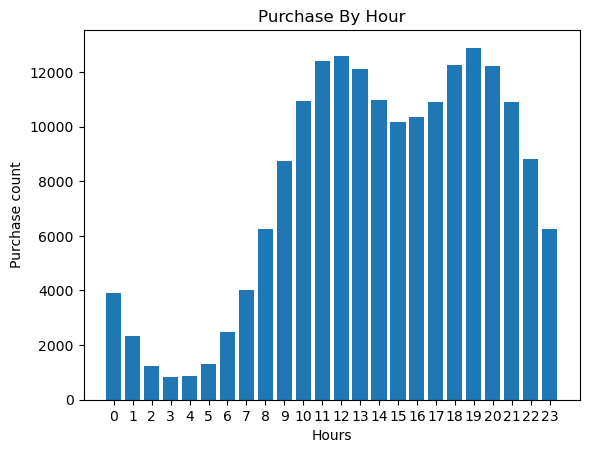

In [241]:
x = Hourly_Purchase.index
y = Hourly_Purchase.values
plt.bar(x,y)
plt.xticks(range(0,24))
plt.title("Purchase By Hour")
plt.xlabel("Hours")
plt.ylabel("Purchase count")
plt.savefig("Purchase By Hour")
plt.show()

It highlights that 11-12 hour and 19 hour has the highest frequency of purchases. This visualization helps identify peak hours when customers are most active.

Visualizing the Distribution of Purchases by Hour

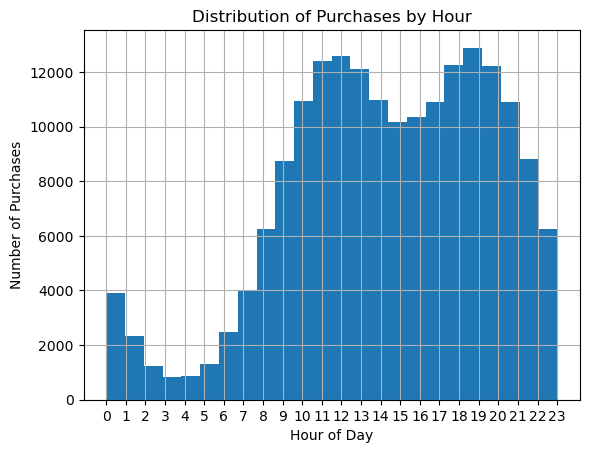

In [242]:
plt.hist(Sales_USA.Hour, bins=24)   # Histogram usually needs 1 variable (x)

plt.title("Distribution of Purchases by Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Number of Purchases")

plt.xticks(range(0,24))

plt.grid(True)
plt.savefig("Number of Purchases By Hour")
plt.show()

If you want to show KDE Curve ( Kernel Density Estimation) -- It is a smooth version of the histogram.
Instead of bars, it shows the overall trend smoothly. Then you need to use seaborn.

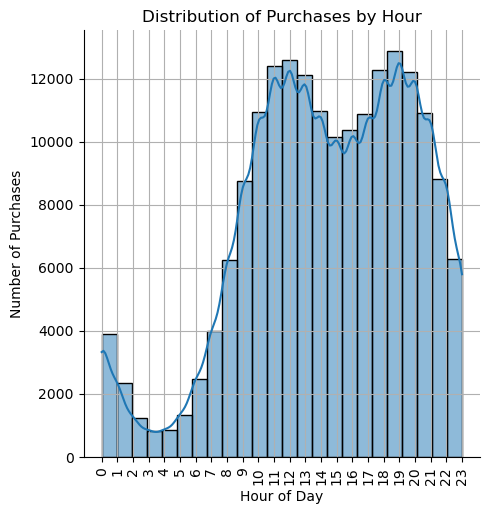

In [243]:
sns.displot(x = Sales_USA.Hour, kde=True, bins=24)  # displot is histogram 
plt.title('Distribution of Purchases by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Purchases')
plt.grid(True)
plt.xticks(range(0, 24), rotation = 90)
plt.savefig("Distribution of Purchases by Hour")
plt.show()

The distribution plot with a KDE curve shows the frequency of purchases throughout the day. The plot reveals 12 and 19 hours have the highest density of purchases, indicating the optimal times for displaying advertisements. The grid and x-axis labels make the plot easy to interpret, showing that the highest number of purchases typically occurs in the afternoon or late evening hours, suggesting these times might be ideal for ad placements.

#### Task 11. Which product was sold the least as per your categories and what might be the reason behind that. Explain your analysis.

In [244]:
Sales_USA

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,product_no,Day,Month,Year,Time,Price Rounded,Pin,City,Product Category,Total Sales,Hour
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",1,19,4,2019,08:46:00,12,75001,Dallas,Charging Cable,24,8
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",2,7,4,2019,22:30:00,100,02215,Boston,Headphone,100,22
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",3,12,4,2019,14:38:00,600,90001,Los Angeles,Phone,600,14
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,12,4,2019,14:38:00,12,90001,Los Angeles,Headphone,12,14
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,30,4,2019,09:27:00,12,90001,Los Angeles,Headphone,12,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.99,2019-09-17 20:56:00,"840 Highland St, Los Angeles, CA 90001",10,17,9,2019,20:56:00,3,90001,Los Angeles,Batteries,9,20
186846,259354,iPhone,1,700.00,2019-09-01 16:00:00,"216 Dogwood St, San Francisco, CA 94016",11,1,9,2019,16:00:00,700,94016,San Francisco,Phone,700,16
186847,259355,iPhone,1,700.00,2019-09-23 07:39:00,"220 12th St, San Francisco, CA 94016",11,23,9,2019,07:39:00,700,94016,San Francisco,Phone,700,7
186848,259356,34in Ultrawide Monitor,1,379.99,2019-09-19 17:30:00,"511 Forest St, San Francisco, CA 94016",19,19,9,2019,17:30:00,380,94016,San Francisco,Monitor,380,17


In [245]:
# creating tables for comprehensive view

In [246]:
Product_count = Sales_USA.groupby("Product Category")["Product"].value_counts().reset_index(name = "Count")  
Product_count.sort_values(by = "Count")                             # groupby creates hierarchical index (multi-index)
                                                                   # reset_index() converts indexes into normal columns


,Product Category,Product,Count
8,Home Appliances,LG Dryer,646
7,Home Appliances,LG Washing Machine,666
17,Phone,Vareebadd Phone,2065
14,Monitor,20in Monitor,4098
10,Laptop,ThinkPad Laptop,4126
9,Laptop,Macbook Pro Laptop,4721
18,TV,Flatscreen TV,4794
16,Phone,Google Phone,5522
13,Monitor,34in Ultrawide Monitor,6174
12,Monitor,27in 4K Gaming Monitor,6225


In [247]:
Product_count

,Product Category,Product,Count
0,Batteries,AAA Batteries (4-pack),20612
1,Batteries,AA Batteries (4-pack),20558
2,Charging Cable,USB-C Charging Cable,21859
3,Charging Cable,Lightning Charging Cable,21610
4,Headphone,Wired Headphones,18849
5,Headphone,Apple Airpods Headphones,15525
6,Headphone,Bose SoundSport Headphones,13298
7,Home Appliances,LG Washing Machine,666
8,Home Appliances,LG Dryer,646
9,Laptop,Macbook Pro Laptop,4721


The output shows the count of sales for each product within its category. From this, it is evident that the products with the least sales are the LG Washing Machine and LG Dryer, with counts of 666 and 646, respectively, in the 'Home appliances' category. These are the least sold products among the listed categories.

##### Calculating Mean Price per Product


In [248]:
mean_price = Sales_USA.groupby("Product")["Price Each"].mean().reset_index()
mean_price

,Product,Price Each
0,20in Monitor,109.99
1,27in 4K Gaming Monitor,389.99
2,27in FHD Monitor,149.99
3,34in Ultrawide Monitor,379.99
4,AA Batteries (4-pack),3.84
5,AAA Batteries (4-pack),2.99
6,Apple Airpods Headphones,150.00
7,Bose SoundSport Headphones,99.99
8,Flatscreen TV,300.00
9,Google Phone,600.00


In [249]:
mean_price = Sales_USA.groupby("Product")["Price Each"].mean().reset_index(name = "Mean Price")
mean_price

,Product,Mean Price
0,20in Monitor,109.99
1,27in 4K Gaming Monitor,389.99
2,27in FHD Monitor,149.99
3,34in Ultrawide Monitor,379.99
4,AA Batteries (4-pack),3.84
5,AAA Batteries (4-pack),2.99
6,Apple Airpods Headphones,150.00
7,Bose SoundSport Headphones,99.99
8,Flatscreen TV,300.00
9,Google Phone,600.00


The mean price data reveals that products like the LG Washing Machine and LG Dryer are priced at 600.00 dollars , which is relatively high compared to other products in the dataset. This suggests that their high prices may be a contributing factor to their lower sales volumes.

##### Merging Sales Count with Mean Price

In [250]:
merged = pd.merge(Product_count, mean_price, on = "Product" , how ="left")
merged

,Product Category,Product,Count,Mean Price
0,Batteries,AAA Batteries (4-pack),20612,2.99
1,Batteries,AA Batteries (4-pack),20558,3.84
2,Charging Cable,USB-C Charging Cable,21859,11.95
3,Charging Cable,Lightning Charging Cable,21610,14.95
4,Headphone,Wired Headphones,18849,11.99
5,Headphone,Apple Airpods Headphones,15525,150.00
6,Headphone,Bose SoundSport Headphones,13298,99.99
7,Home Appliances,LG Washing Machine,666,600.00
8,Home Appliances,LG Dryer,646,600.00
9,Laptop,Macbook Pro Laptop,4721,1700.00


The merged data provides a comprehensive view of both the sales count and mean price for each product. The LG Washing Machine and LG Dryer have the lowest sales counts and are also among the higher-priced items. This pricing could be a significant factor in their low sales, as higher-priced products may have a smaller customer base or face more competition compared to lower-priced items.

Conclusion :
The analysis indicates that the LG Washing Machine and LG Dryer were sold the least. Their high prices, relative to other products, likely contribute to their lower sales volumes. Higher-priced items may have fewer buyers due to budget constraints or lower demand compared to more affordable products. Additionally, factors such as product necessity, market competition, and customer preferences may also influence the sales figures.

#### Task 12. Which product is most likely to be sold more during winter season, summer season and rainy season? Explain the possible reason behind the High-Volume Sale

The task is to determine which products are most likely to be sold more during different seasons (winter, summer, and rainy) and to explain the reasons behind these seasonal sales trends.

In [251]:
# creating a function

In [252]:
def season(data):
    if data in [11,12,1,2]: 
        return "Winter"
    elif data in [3,4,5,6]:  
        return "Summer"
    elif data in [7,8,9,10]: 
        return "Rainy"
    else :                  
        return np.nan
    
Sales_USA["Season"] = Sales_USA.Month.apply(season)
Sales_USA.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,product_no,Day,Month,Year,Time,Price Rounded,Pin,City,Product Category,Total Sales,Hour,Season
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",1,19,4,2019,08:46:00,12,75001,Dallas,Charging Cable,24,8,Summer
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",2,7,4,2019,22:30:00,100,02215,Boston,Headphone,100,22,Summer
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",3,12,4,2019,14:38:00,600,90001,Los Angeles,Phone,600,14,Summer
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,12,4,2019,14:38:00,12,90001,Los Angeles,Headphone,12,14,Summer
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,30,4,2019,09:27:00,12,90001,Los Angeles,Headphone,12,9,Summer


In [253]:
Sale_By_Season = Sales_USA.groupby("Season")["Product"].value_counts().reset_index( name = "Sale Count")
Sale_By_Season

,Season,Product,Sale Count
0,Rainy,USB-C Charging Cable,6894
1,Rainy,Lightning Charging Cable,6782
2,Rainy,AA Batteries (4-pack),6466
3,Rainy,AAA Batteries (4-pack),6409
4,Rainy,Wired Headphones,5889
5,Rainy,Apple Airpods Headphones,4831
6,Rainy,Bose SoundSport Headphones,4180
7,Rainy,27in FHD Monitor,2351
8,Rainy,iPhone,2051
9,Rainy,27in 4K Gaming Monitor,2018


The output shows which products have the highest sales counts for each season. The most popular products by season are:

Winter: USB-C Charging Cable

Summer: Lightning Charging Cable

Rainy: USB-C Charging Cable 

This indicates that certain products perform better during specific seasons.

##### using seaborn for grouped bar chart or separete bar chart for each season. 

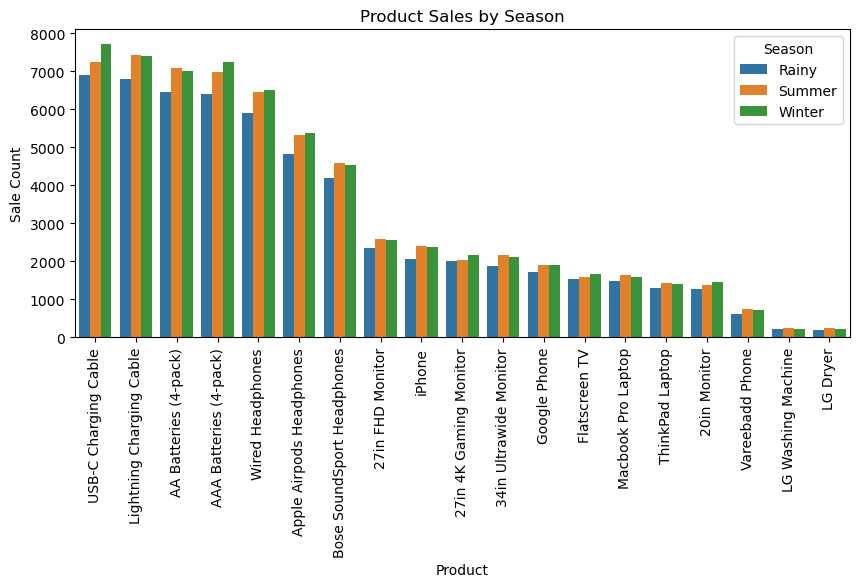

In [254]:
plt.figure(figsize=(10,4))

sns.barplot(
    data = Sale_By_Season,
    x= "Product",
    y= "Sale Count",
    hue= "Season"
)

plt.title("Product Sales by Season")

plt.xticks(rotation = 90)

plt.show()

he count plot visually represents the sales of different products across seasons. It confirms that:

Winter: USB-C Charging Cable is the top-selling product.

Summer: Lightning Charging Cable leads in sales.

Rainy: USB-C Charging Cable also performs well.

Conclusion :

#### Winter: 
The USB-C Charging Cable tops the sales list, likely because people may purchase more tech accessories during the colder months when they stay indoors more often and might need additional charging solutions for their devices.

#### Summer: 
The Lightning Charging Cable leads in sales. During summer, people might be on the go more frequently and need portable charging solutions, which explains the higher sales of this product.

#### Rainy: 
The USB-C Charging Cable again stands out. Rainy weather often leads to increased indoor activities, which could drive higher sales of tech products as people spend more time using their electronic devices.

Overall, these trends highlight how seasonal weather and activities influence purchasing behavior, suggesting that advertisements and promotions could be tailored to these seasonal patterns to maximize sales.

#### Task 13. Which phone is sold most during the month of March?

In [255]:
Sales_USA

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,product_no,Day,Month,Year,Time,Price Rounded,Pin,City,Product Category,Total Sales,Hour,Season
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",1,19,4,2019,08:46:00,12,75001,Dallas,Charging Cable,24,8,Summer
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",2,7,4,2019,22:30:00,100,02215,Boston,Headphone,100,22,Summer
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",3,12,4,2019,14:38:00,600,90001,Los Angeles,Phone,600,14,Summer
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,12,4,2019,14:38:00,12,90001,Los Angeles,Headphone,12,14,Summer
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,30,4,2019,09:27:00,12,90001,Los Angeles,Headphone,12,9,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.99,2019-09-17 20:56:00,"840 Highland St, Los Angeles, CA 90001",10,17,9,2019,20:56:00,3,90001,Los Angeles,Batteries,9,20,Rainy
186846,259354,iPhone,1,700.00,2019-09-01 16:00:00,"216 Dogwood St, San Francisco, CA 94016",11,1,9,2019,16:00:00,700,94016,San Francisco,Phone,700,16,Rainy
186847,259355,iPhone,1,700.00,2019-09-23 07:39:00,"220 12th St, San Francisco, CA 94016",11,23,9,2019,07:39:00,700,94016,San Francisco,Phone,700,7,Rainy
186848,259356,34in Ultrawide Monitor,1,379.99,2019-09-19 17:30:00,"511 Forest St, San Francisco, CA 94016",19,19,9,2019,17:30:00,380,94016,San Francisco,Monitor,380,17,Rainy


In [256]:
Sales_USA.query("Month == 3 and `Product Category` == 'Phone'") # if space is there in a column name then u need to use backtick
                                                                # string should be in quotes

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,product_no,Day,Month,Year,Time,Price Rounded,Pin,City,Product Category,Total Sales,Hour,Season
105263,162009,iPhone,1,700.0,2019-03-28 20:59:00,"942 Church St, Austin, TX 73301",11,28,3,2019,20:59:00,700,73301,Austin,Phone,700,20,Summer
105282,162026,iPhone,1,700.0,2019-03-22 22:31:00,"71 Pine St, Austin, TX 73301",11,22,3,2019,22:31:00,700,73301,Austin,Phone,700,22,Summer
105286,162030,Google Phone,1,600.0,2019-03-09 16:50:00,"463 4th St, San Francisco, CA 94016",3,9,3,2019,16:50:00,600,94016,San Francisco,Phone,600,16,Summer
105289,162033,iPhone,1,700.0,2019-03-19 11:06:00,"267 Johnson St, Dallas, TX 75001",11,19,3,2019,11:06:00,700,75001,Dallas,Phone,700,11,Summer
105293,162037,iPhone,1,700.0,2019-03-23 02:11:00,"277 Elm St, Los Angeles, CA 90001",11,23,3,2019,02:11:00,700,90001,Los Angeles,Phone,700,2,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120410,176484,iPhone,1,700.0,2019-03-17 15:59:00,"985 Willow St, San Francisco, CA 94016",11,17,3,2019,15:59:00,700,94016,San Francisco,Phone,700,15,Summer
120415,176487,iPhone,1,700.0,2019-03-14 14:46:00,"92 Johnson St, Los Angeles, CA 90001",11,14,3,2019,14:46:00,700,90001,Los Angeles,Phone,700,14,Summer
120418,176489,Google Phone,1,600.0,2019-03-10 19:19:00,"880 Hickory St, New York City, NY 10001",3,10,3,2019,19:19:00,600,10001,New York City,Phone,600,19,Summer
120479,176549,iPhone,1,700.0,2019-03-20 01:24:00,"604 Park St, Los Angeles, CA 90001",11,20,3,2019,01:24:00,700,90001,Los Angeles,Phone,700,1,Summer


#### OR

In [257]:
marphsale = Sales_USA[(Sales_USA["Month"] == 3) & (Sales_USA["Product Category"] == 'Phone')]

marphsale.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,product_no,Day,Month,Year,Time,Price Rounded,Pin,City,Product Category,Total Sales,Hour,Season
105263,162009,iPhone,1,700.0,2019-03-28 20:59:00,"942 Church St, Austin, TX 73301",11,28,3,2019,20:59:00,700,73301,Austin,Phone,700,20,Summer
105282,162026,iPhone,1,700.0,2019-03-22 22:31:00,"71 Pine St, Austin, TX 73301",11,22,3,2019,22:31:00,700,73301,Austin,Phone,700,22,Summer
105286,162030,Google Phone,1,600.0,2019-03-09 16:50:00,"463 4th St, San Francisco, CA 94016",3,9,3,2019,16:50:00,600,94016,San Francisco,Phone,600,16,Summer
105289,162033,iPhone,1,700.0,2019-03-19 11:06:00,"267 Johnson St, Dallas, TX 75001",11,19,3,2019,11:06:00,700,75001,Dallas,Phone,700,11,Summer
105293,162037,iPhone,1,700.0,2019-03-23 02:11:00,"277 Elm St, Los Angeles, CA 90001",11,23,3,2019,02:11:00,700,90001,Los Angeles,Phone,700,2,Summer


In [258]:
# frequency of values in Product column

marphsale.Product.value_counts()

Product
iPhone             537
Google Phone       463
Vareebadd Phone    174
Name: count, dtype: int64

The output reveals the number of units sold for each phone model in March:

iPhone: 537 units

Google Phone: 463 units

Vareebadd Phone: 174 units.

The iPhone was the most sold phone model in March, followed by the Google Phone and Vareebadd Phone.

Conclusion :

The iPhone led in sales during March with 537 units sold, significantly outperforming other phone models. This high volume of sales might be attributed to factors such as brand popularity, promotions, or consumer preferences for the iPhone. The analysis highlights which phone model resonates most with customers in March, providing valuable insights for inventory management, marketing strategies, and sales forecasting.

#### Task 14. Which headphones are the most expensive?

In [259]:
Sales_USA

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,product_no,Day,Month,Year,Time,Price Rounded,Pin,City,Product Category,Total Sales,Hour,Season
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",1,19,4,2019,08:46:00,12,75001,Dallas,Charging Cable,24,8,Summer
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",2,7,4,2019,22:30:00,100,02215,Boston,Headphone,100,22,Summer
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",3,12,4,2019,14:38:00,600,90001,Los Angeles,Phone,600,14,Summer
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,12,4,2019,14:38:00,12,90001,Los Angeles,Headphone,12,14,Summer
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,30,4,2019,09:27:00,12,90001,Los Angeles,Headphone,12,9,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.99,2019-09-17 20:56:00,"840 Highland St, Los Angeles, CA 90001",10,17,9,2019,20:56:00,3,90001,Los Angeles,Batteries,9,20,Rainy
186846,259354,iPhone,1,700.00,2019-09-01 16:00:00,"216 Dogwood St, San Francisco, CA 94016",11,1,9,2019,16:00:00,700,94016,San Francisco,Phone,700,16,Rainy
186847,259355,iPhone,1,700.00,2019-09-23 07:39:00,"220 12th St, San Francisco, CA 94016",11,23,9,2019,07:39:00,700,94016,San Francisco,Phone,700,7,Rainy
186848,259356,34in Ultrawide Monitor,1,379.99,2019-09-19 17:30:00,"511 Forest St, San Francisco, CA 94016",19,19,9,2019,17:30:00,380,94016,San Francisco,Monitor,380,17,Rainy


In [271]:
hdphones = Sales_USA[Sales_USA["Product Category"] == "Headphone"]
hdphones.sort_values( by = "Price Each", ascending = False).head()




,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,product_no,Day,Month,Year,Time,Price Rounded,Pin,City,Product Category,Total Sales,Hour,Season
186843,259351,Apple Airpods Headphones,1,150.0,2019-09-01 19:43:00,"981 4th St, New York City, NY 10001",9,1,9,2019,19:43:00,150,10001,New York City,Headphone,150,19,Rainy
126818,200106,Apple Airpods Headphones,1,150.0,2019-05-07 22:39:00,"275 Wilson St, Los Angeles, CA 90001",9,7,5,2019,22:39:00,150,90001,Los Angeles,Headphone,150,22,Summer
53458,317695,Apple Airpods Headphones,1,150.0,2019-12-29 16:30:00,"283 Johnson St, San Francisco, CA 94016",9,29,12,2019,16:30:00,150,94016,San Francisco,Headphone,150,16,Winter
126795,200084,Apple Airpods Headphones,1,150.0,2019-05-27 16:07:00,"503 12th St, New York City, NY 10001",9,27,5,2019,16:07:00,150,10001,New York City,Headphone,150,16,Summer
126803,200092,Apple Airpods Headphones,1,150.0,2019-05-31 18:58:00,"398 Hill St, Dallas, TX 75001",9,31,5,2019,18:58:00,150,75001,Dallas,Headphone,150,18,Summer


The output reveals that the Apple Airpods Headphones are the most expensive headphones, priced at 150.00 dollars.

Conclusion:
The Apple Airpods Headphones are the most expensive headphones in the dataset, with a price of $150.00. This high price point is likely due to the brand's premium positioning, advanced features, or market demand. Understanding the pricing of different products helps in pricing strategy decisions, market positioning, and inventory management.

#### Task 15. Check if the price of any product is changing in different months. If yes, explain the possible reason behind the price change

In [274]:

s = Sales_USA.groupby(["Product","Month"])["Price Each"].mean()
s

Product       Month
20in Monitor  1        109.99
              2        109.99
              3        109.99
              4        109.99
              5        109.99
                        ...  
iPhone        8        700.00
              9        700.00
              10       700.00
              11       700.00
              12       700.00
Name: Price Each, Length: 228, dtype: float64

In [279]:
# converting series into Dataframe
pricechange = pd.DataFrame(s)
pd.set_option('display.max_rows', 100)
# pd.set_option('display.max_rows', None)    --- # show all rows and columns
# pd.set_option('display.max_columns', None) ----
pricechange

Price Each
Product      Month            
20in Monitor 1          109.99
             2          109.99
             3          109.99
             4          109.99
             5          109.99
...                        ...
iPhone       8          700.00
             9          700.00
             10         700.00
             11         700.00
             12         700.00

[228 rows x 1 columns]

The result shows that there was no observed change in the average price of any product across different months. This implies that the prices remained consistent throughout the year.

#### Task 16. People prefer which product more in earphones, wired or wireless?


In [294]:
hdphones["Product"].value_counts().reset_index(name = "Count")

,Product,Count
0,Wired Headphones,18849
1,Apple Airpods Headphones,15525
2,Bose SoundSport Headphones,13298


If we consider "bose soundsport headphones" to be wireless we can see that sum of apple and bose headphones (wireless) is greater than wired headphones, ie, 28823(sum of apple and bose headphones sold) > 18849 (wired headphones sold ).

#### Task 17. Which product in every category in more likely to be ordered in bulk?

In [296]:
# Filter bulk orders
bulk_orders = Sales_USA[Sales_USA["Quantity Ordered"] > 1]

bulk_products = bulk_orders.groupby("Product Category")["Product"].value_counts().reset_index(name="Bulk Count")
bulk_products 

,Product Category,Product,Bulk Count
0,Batteries,AAA Batteries (4-pack),6913
1,Batteries,AA Batteries (4-pack),5243
2,Charging Cable,USB-C Charging Cable,1884
3,Charging Cable,Lightning Charging Cable,1448
4,Headphone,Wired Headphones,1521
5,Headphone,Bose SoundSport Headphones,130
6,Headphone,Apple Airpods Headphones,111
7,Laptop,Macbook Pro Laptop,4
8,Laptop,ThinkPad Laptop,2
9,Monitor,27in FHD Monitor,43


In [300]:
bulk_products.groupby("Product Category").head(1)  # takes FIRST/top product from each category.

,Product Category,Product,Bulk Count
0,Batteries,AAA Batteries (4-pack),6913
2,Charging Cable,USB-C Charging Cable,1884
4,Headphone,Wired Headphones,1521
7,Laptop,Macbook Pro Laptop,4
9,Monitor,27in FHD Monitor,43
13,Phone,Google Phone,7
16,TV,Flatscreen TV,19


In [301]:
bulk_orders

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,product_no,Day,Month,Year,Time,Price Rounded,Pin,City,Product Category,Total Sales,Hour,Season
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",1,19,4,2019,08:46:00,12,75001,Dallas,Charging Cable,24,8,Summer
28,176583,AAA Batteries (4-pack),2,2.99,2019-04-20 12:00:00,"146 Jackson St, Portland, OR 97035",10,20,4,2019,12:00:00,3,97035,Portland,Batteries,6,12,Summer
32,176586,AAA Batteries (4-pack),2,2.99,2019-04-10 17:00:00,"365 Center St, San Francisco, CA 94016",10,10,4,2019,17:00:00,3,94016,San Francisco,Batteries,6,17,Summer
40,176593,Lightning Charging Cable,2,14.95,2019-04-15 13:45:00,"906 7th St, Portland, OR 97035",6,15,4,2019,13:45:00,15,97035,Portland,Charging Cable,30,13,Summer
42,176595,Wired Headphones,3,11.99,2019-04-02 09:11:00,"383 6th St, Los Angeles, CA 90001",4,2,4,2019,09:11:00,12,90001,Los Angeles,Headphone,36,9,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186829,259338,AAA Batteries (4-pack),2,2.99,2019-09-02 21:29:00,"666 Lakeview St, Boston, MA 02215",10,2,9,2019,21:29:00,3,02215,Boston,Batteries,6,21,Rainy
186830,259339,USB-C Charging Cable,2,11.95,2019-09-12 23:43:00,"509 Park St, Austin, TX 73301",1,12,9,2019,23:43:00,12,73301,Austin,Charging Cable,24,23,Rainy
186831,259340,AA Batteries (4-pack),2,3.84,2019-09-18 20:18:00,"544 Hickory St, Los Angeles, CA 90001",8,18,9,2019,20:18:00,4,90001,Los Angeles,Batteries,8,20,Rainy
186835,259344,AAA Batteries (4-pack),2,2.99,2019-09-10 23:33:00,"721 Madison St, San Francisco, CA 94016",10,10,9,2019,23:33:00,3,94016,San Francisco,Batteries,6,23,Rainy


In [302]:
bulk = Sales_USA.groupby(
    ["Product Category", "Product"]
)["Quantity Ordered"].max().reset_index()

bulk

,Product Category,Product,Quantity Ordered
0,Batteries,AA Batteries (4-pack),7
1,Batteries,AAA Batteries (4-pack),9
2,Charging Cable,Lightning Charging Cable,4
3,Charging Cable,USB-C Charging Cable,6
4,Headphone,Apple Airpods Headphones,3
5,Headphone,Bose SoundSport Headphones,3
6,Headphone,Wired Headphones,4
7,Home Appliances,LG Dryer,1
8,Home Appliances,LG Washing Machine,1
9,Laptop,Macbook Pro Laptop,2


In [306]:
bulk.sort_values(
    "Quantity Ordered",
    ascending=False
)

,Product Category,Product,Quantity Ordered
1,Batteries,AAA Batteries (4-pack),9
0,Batteries,AA Batteries (4-pack),7
3,Charging Cable,USB-C Charging Cable,6
2,Charging Cable,Lightning Charging Cable,4
6,Headphone,Wired Headphones,4
4,Headphone,Apple Airpods Headphones,3
5,Headphone,Bose SoundSport Headphones,3
13,Monitor,27in FHD Monitor,2
17,Phone,iPhone,2
16,Phone,Vareebadd Phone,2


Among the headphones, the Wired Headphones are most likely to be ordered in bulk, with the highest maximum order quantity of 4.

In [ ]:
# ONLY top product in each category

In [305]:
bulk.sort_values(
    by ="Quantity Ordered",
    ascending=False
).groupby("Product Category").head(1)

,Product Category,Product,Quantity Ordered
1,Batteries,AAA Batteries (4-pack),9
3,Charging Cable,USB-C Charging Cable,6
6,Headphone,Wired Headphones,4
13,Monitor,27in FHD Monitor,2
17,Phone,iPhone,2
9,Laptop,Macbook Pro Laptop,2
18,TV,Flatscreen TV,2
8,Home Appliances,LG Washing Machine,1


In [ ]:
# 1st is how often a product is oredred in bulk?  how frequently product is bulk ordered?
# 2nd  one is how much at maximum? highest quantity ordered at once?

### Overall Conclusion and Summary

##### Data Cleaning and Transformation:

Conversion of Categorical to Numeric: 
Converted text-based columns like Product into numerical formats for easier analysis.

Date Parsing: 
Split Order Date into separate columns for Day, Month, Year, and Time to facilitate time-based analysis.

Price Rounding:
Created a Price Rounded column for simplicity in cost-related calculations.

PIN Code Extraction: 
Extracted PIN codes from the Purchase Address for geographical analysis.

City Extraction: 
Isolated city names from addresses for city-based sales analysis.

Product Categorization:
Grouped products into categories (e.g., Phones, Accessories) to analyze sales trends within these categories.

##### Exploratory Data Analysis (EDA):

Best Month for Sales: 

-Identified December as the best month for sales, with the highest total revenue. 
This suggests that end-of-year sales and holidays drive higher sales volumes.

City with Highest Sales: 

-Found that San Francisco had the highest number of product sales, indicating it as a major market for the products.
Optimal Advertisement Time: Determined that the most purchases occur in the evening hours, suggesting that advertising during these times might be more effective.

Least Sold Product:

-Identified LG Washing Machine as the least sold product. The lower sales could be due to its high price compared to other products or lower consumer demand.

Seasonal Sales Patterns:

Winter:

USB-C Charging Cable is the most popular, likely due to increased indoor activity and device usage.

Summer: 

Lightning Charging Cable sees higher sales, possibly due to the need for portable charging solutions during travel.

Rainy Season: 

USB-C Charging Cable leads in sales again, indicating higher indoor activities during the rainy season.

Most Expensive Headphones:

Apple Airpods Headphones are the most expensive, priced at D 150, reflecting their premium market positioning.
Bulk Orders by Product Category: For the Headphones category, Wired Headphones are most frequently ordered in larger quantities compared to other products.

##### Recommendations:

Marketing Strategy: Focus advertising efforts around December and in the evenings to capture peak purchasing times.

City-Specific Marketing: Tailor marketing and sales strategies for San Francisco to leverage its high sales potential.

Seasonal Promotions: Adjust product promotions and inventory based on seasonal trends to maximize sales during peak periods.

Product Pricing and Inventory: Consider revising the pricing strategy for high-ticket items like LG Washing Machines and analyze potential factors affecting their sales.